# EVALUACIÓN 2 – Modelado Predictivo de Ingresos Recurrentes (MRR)
### Regresión lineal para predecir el MRR del próximo trimestre de SaaSFlow

---

**Integrantes:**

<table>
<tr>
<td>Juan Riquelme</td>
<td>Yoseph Rodríguez</td>
<td>Andrew Sepúlveda</td>
<td>Felipe Soto</td>
</tr>
</table>

**Asignatura:** Inteligencia Artificial

**Fecha:** 01 de octubre de 2026


---

## Descripción

La dirección comercial de **SaaSFlow** necesita estimar el **Ingreso Mensual Recurrente del próximo trimestre** (`mrr_proximo_trimestre`, en USD) de sus clientes B2B, con el objetivo de anticipar posibles fugas de ingresos y apoyar la asignación de recursos de Customer Success.

En este notebook se desarrolla el proceso de análisis y modelado siguiendo las cuatro fases solicitadas en la evaluación:

1. **Fase 1** – Diagnóstico y calidad de datos (EDA)
2. **Fase 2** – Limpieza y tratamiento de datos (nulos, ingeniería de características, codificación, escalado)
3. **Fase 3** – Construcción del modelo (partición train/test y regresión lineal)
4. **Fase 4** – Evaluación e interpretación de métricas (R² y MAE)

Para el preprocesamiento y entrenamiento se utiliza un **Pipeline**, de manera que las transformaciones se ajusten utilizando únicamente los datos de entrenamiento y así evitar fuga de datos (`data leakage`).

## Requisitos de software

Python 3.10+ con: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`.

---

## Carga de librerías y del dataset

In [124]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [125]:
!wget https://raw.githubusercontent.com/JRiquelmeP/C2-IA/main/E2-Regresi%C3%B3n/clientes_mrr_dataset.csv

--2026-10-01 21:55:43--  https://raw.githubusercontent.com/JRiquelmeP/C2-IA/main/E2-Regresi%C3%B3n/clientes_mrr_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3527824 (3.4M) [text/plain]
Saving to: ‘clientes_mrr_dataset.csv’

clientes_mrr_datase 100%[===================>]   3.36M  15.1MB/s    in 0.2s    

2026-10-01 21:55:43 (15.1 MB/s) - ‘clientes_mrr_dataset.csv’ saved [3527824/3527824]



In [126]:
data = pd.read_csv("clientes_mrr_dataset.csv")
print(f"Filas: {data.shape[0]:,} | Columnas: {data.shape[1]}")
data.head()

Filas: 30,000 | Columnas: 11


,id_cliente,fecha_registro,sector_empresa,tamano_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,duracion_contrato,gasto_mkt_asociado,pago_puntual,mrr_proximo_trimestre
0,CLI-0001,2025-09-14 00:24:49.009633632,Finanzas,Mediana,3.000,34.351,7.000,Mensual,"3,932.342",Si,706.160
1,CLI-0002,2024-02-12 19:17:24.874829152,Tecnologia,Mediana,NaN,28.686,8.000,Mensual,"2,547.833",No,555.950
2,CLI-0003,2021-02-03 13:56:48.713623787,Tecnologia,Pequeña,5.000,50.027,7.000,2 Años,"3,203.233",Si,755.530
3,CLI-0004,2021-08-19 03:21:50.803693456,Educacion,Pequeña,0.000,NaN,9.000,Anual,603.209,No,364.940
4,CLI-0005,2021-09-26 05:21:16.482549416,Educacion,Grande,3.000,NaN,8.000,Anual,864.789,Si,"1,611.930"


---
## Objetivo

Predecir el **MRR esperado del próximo trimestre** (`mrr_proximo_trimestre`, USD) de cada cliente a partir de sus características de uso, soporte, contrato y tamaño, con el fin de **anticipar posibles fugas de ingresos y apoyar la asignación de recursos del equipo de Customer Success**.

---
---
# Fase 1 – Diagnóstico y calidad de datos (EDA)

En esta fase se analiza el estado inicial de los datos para identificar problemas de calidad, valores nulos, tipos de datos inconsistentes y posibles valores atípicos. Estos resultados servirán como base para las decisiones de limpieza y preprocesamiento aplicadas posteriormente.

---
## 1.1 Tipos de datos e inconsistencias de tipo

In [127]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             30000 non-null  object 
 1   fecha_registro         30000 non-null  object 
 2   sector_empresa         30000 non-null  object 
 3   tamano_empresa         30000 non-null  object 
 4   tickets_soporte        27536 non-null  float64
 5   promedio_sesiones_mes  28455 non-null  float64
 6   satisfaccion_nps       26403 non-null  float64
 7   duracion_contrato      30000 non-null  object 
 8   gasto_mkt_asociado     30000 non-null  float64
 9   pago_puntual           30000 non-null  object 
 10  mrr_proximo_trimestre  30000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 2.5+ MB


**Lectura:** `fecha_registro` viene como texto (`str`/`object`), no como fecha: es un tipo **inconsistente** para su naturaleza y hay que convertirla para poder calcular la antigüedad. Las variables `sector_empresa`, `tamano_empresa`, `duracion_contrato` y `pago_puntual` son categóricas en texto y **no están codificadas**: un modelo lineal necesita números.

In [128]:
tipos = pd.DataFrame({
    "dtype_actual": data.dtypes.astype(str),
    "tipo_esperado": ["identificador", "fecha", "categórica nominal", "categórica ordinal",
                      "numérica (conteo)", "numérica continua", "numérica (escala 1-10)",
                      "categórica ordinal", "numérica continua", "categórica binaria",
                      "numérica continua (objetivo)"],
})
tipos

,dtype_actual,tipo_esperado
id_cliente,object,identificador
fecha_registro,object,fecha
sector_empresa,object,categórica nominal
tamano_empresa,object,categórica ordinal
tickets_soporte,float64,numérica (conteo)
promedio_sesiones_mes,float64,numérica continua
satisfaccion_nps,float64,numérica (escala 1-10)
duracion_contrato,object,categórica ordinal
gasto_mkt_asociado,float64,numérica continua
pago_puntual,object,categórica binaria


---
## 1.2 Porcentaje de valores nulos por variable

In [129]:
nulos = (data.isna().mean() * 100).round(2).sort_values(ascending=False).rename("% nulos").to_frame()
nulos["n nulos"] = data.isna().sum()
nulos

,% nulos,n nulos
satisfaccion_nps,11.990,3597
tickets_soporte,8.210,2464
promedio_sesiones_mes,5.150,1545
sector_empresa,0.000,0
fecha_registro,0.000,0
id_cliente,0.000,0
tamano_empresa,0.000,0
duracion_contrato,0.000,0
gasto_mkt_asociado,0.000,0
pago_puntual,0.000,0


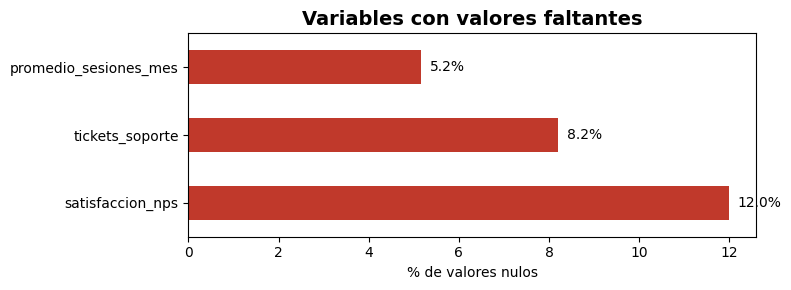

In [130]:
nulos_plot = nulos[nulos["% nulos"] > 0]["% nulos"]
ax = nulos_plot.plot(kind="barh", figsize=(8, 3), color="#c0392b")
ax.set_xlabel("% de valores nulos")
ax.set_title("Variables con valores faltantes", fontsize=14, fontweight="bold")
for i, v in enumerate(nulos_plot):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.show()

**Lectura:** tres variables tienen nulos: `satisfaccion_nps` (~12 %), `tickets_soporte` (~8 %) y `promedio_sesiones_mes` (~5 %). El resto está completo. Ningún porcentaje es lo bastante alto como para descartar la variable, así que se **imputan** (Fase 2).

---
## 1.3 Valores inconsistentes y duplicados

In [131]:
# Rangos imposibles según la metadata
inconsistentes = data[
    (data["tickets_soporte"] < 0) | (data["promedio_sesiones_mes"] < 0) |
    (data["satisfaccion_nps"] < 1) | (data["satisfaccion_nps"] > 10) |
    (data["gasto_mkt_asociado"] < 0) | (data["mrr_proximo_trimestre"] <= 0)
]
print("Registros con valores fuera de rango:", len(inconsistentes))

print("Filas duplicadas completas :", data.duplicated().sum())
print("id_cliente duplicados      :", data["id_cliente"].duplicated().sum())

for col in ["sector_empresa", "tamano_empresa", "duracion_contrato", "pago_puntual"]:
    print(f"\n{col}:", data[col].value_counts(dropna=False).to_dict())

Registros con valores fuera de rango: 0
Filas duplicadas completas : 0
id_cliente duplicados      : 0

sector_empresa: {'Tecnologia': 8913, 'Finanzas': 7530, 'Salud': 6018, 'Retail': 4535, 'Educacion': 3004}

tamano_empresa: {'Pequeña': 14884, 'Mediana': 10479, 'Grande': 4637}

duracion_contrato: {'Mensual': 18087, 'Anual': 8895, '2 Años': 3018}

pago_puntual: {'Si': 24088, 'No': 5912}


**Lectura:** no hay valores fuera de rango, ni duplicados, ni categorías mal escritas. Los problemas de calidad de este dataset son **los nulos**, **el tipo de la fecha** y **el sesgo/atípicos**.

---
## 1.4 Estadísticos descriptivos, sesgo y valores atípicos

In [132]:
num_cols = ["tickets_soporte", "promedio_sesiones_mes", "satisfaccion_nps",
            "gasto_mkt_asociado", "mrr_proximo_trimestre"]
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tickets_soporte,"27,536.000",3.005,1.734,0.000,2.000,3.000,4.000,12.000
promedio_sesiones_mes,"28,455.000",50.131,45.059,5.002,18.086,36.231,67.451,430.701
satisfaccion_nps,"26,403.000",5.914,2.312,1.000,4.000,6.000,8.000,10.000
gasto_mkt_asociado,"30,000.000","2,551.091","1,416.113",100.356,"1,330.525","2,541.074","3,785.665","4,999.954"
mrr_proximo_trimestre,"30,000.000",710.926,337.689,50.000,458.985,642.595,896.705,"3,200.040"


In [133]:
def resumen_atipicos(df, cols):
    filas = []
    for c in cols:
        s = df[c].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lim_inf) | (s > lim_sup)).sum()
        filas.append({
            "variable": c,
            "media": s.mean(),
            "mediana": s.median(),
            "media/mediana": s.mean() / s.median(),
            "asimetría (skew)": s.skew(),
            "std": s.std(),
            "atípicos IQR": n_out,
            "% atípicos": 100 * n_out / len(s),
            "máximo": s.max(),
        })
    return pd.DataFrame(filas).set_index("variable")

resumen_atipicos(data, num_cols)

,media,mediana,media/mediana,asimetría (skew),std,atípicos IQR,% atípicos,máximo
variable,,,,,,,,
tickets_soporte,3.005,3.000,1.002,0.569,1.734,328,1.191,12.000
promedio_sesiones_mes,50.131,36.231,1.384,1.972,45.059,1367,4.804,430.701
satisfaccion_nps,5.914,6.000,0.986,-0.417,2.312,0,0.000,10.000
gasto_mkt_asociado,"2,551.091","2,541.074",1.004,0.004,"1,416.113",0,0.000,"4,999.954"
mrr_proximo_trimestre,710.926,642.595,1.106,1.055,337.689,607,2.023,"3,200.040"


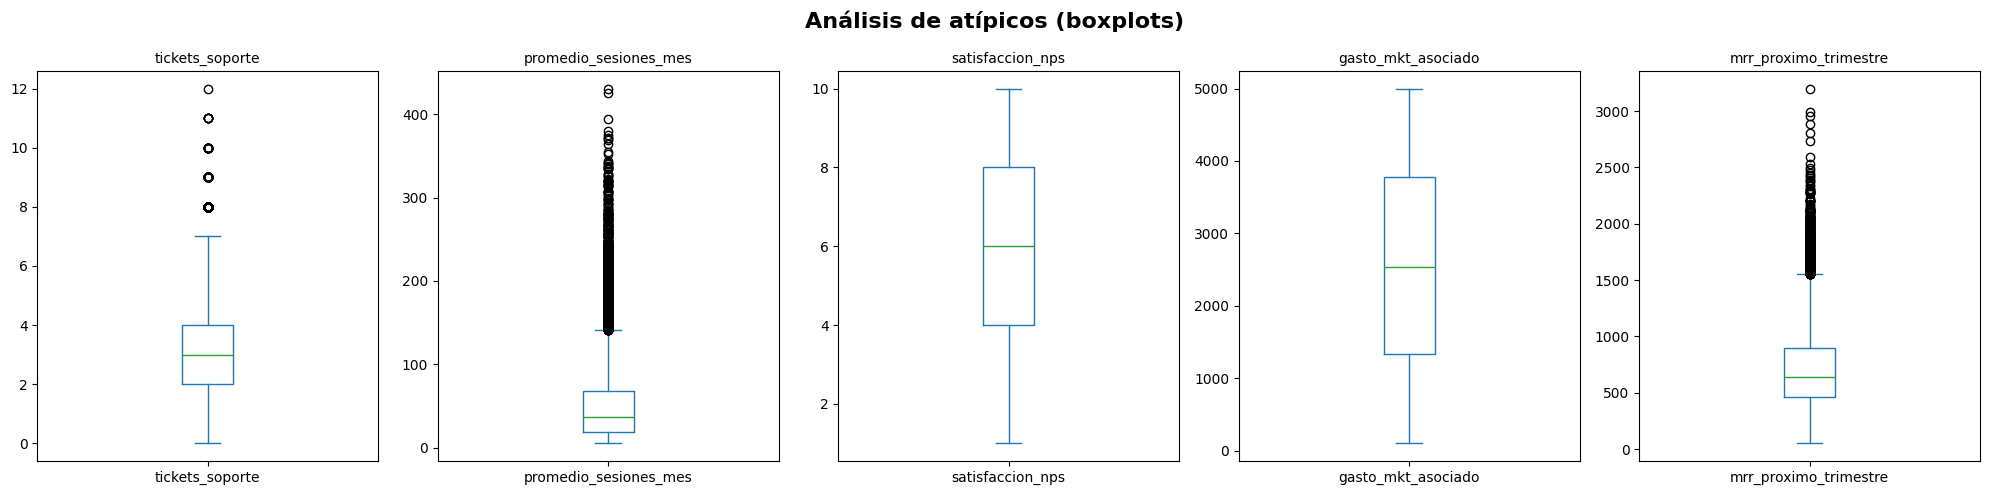

In [134]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, num_cols):
    data[col].plot(kind="box", ax=ax)
    ax.set_title(col, fontsize=10)
plt.suptitle("Análisis de atípicos (boxplots)", fontsize=16, fontweight="bold")
plt.tight_layout(); plt.show()

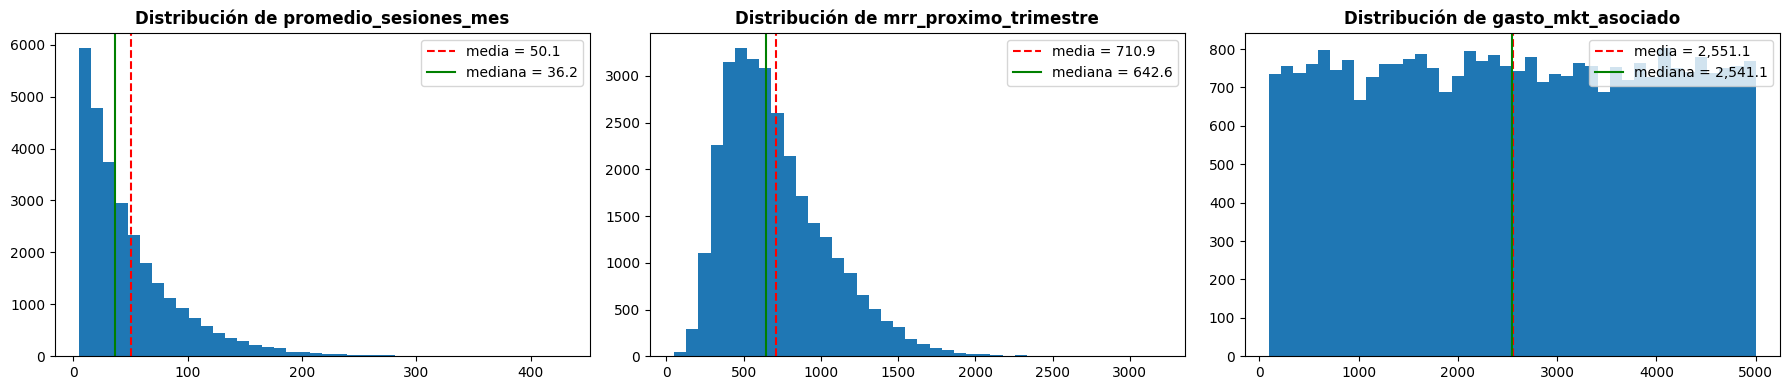

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["promedio_sesiones_mes", "mrr_proximo_trimestre", "gasto_mkt_asociado"]):
    data[col].hist(bins=40, ax=ax, grid=False)
    ax.axvline(data[col].mean(), color="red", ls="--", label=f"media = {data[col].mean():,.1f}")
    ax.axvline(data[col].median(), color="green", ls="-", label=f"mediana = {data[col].median():,.1f}")
    ax.set_title(f"Distribución de {col}", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()

**Lectura (clave para la Fase 2):**

- `promedio_sesiones_mes` es **fuertemente sesgada a la derecha** (asimetría ≈ 2) y tiene más de 1.300 atípicos (~5 %), con máximos por sobre 400 sesiones. Su **media (~50) queda muy por encima de su mediana (~36)**: los atípicos "tiran" la media hacia arriba.
- `mrr_proximo_trimestre` (la variable objetivo) también es asimétrica a la derecha (unos pocos clientes grandes con MRR alto). **No se modifica**: es lo que queremos predecir.
- `tickets_soporte` es un conteo discreto con leve sesgo; `satisfaccion_nps` es una escala 1–10 discreta y sin atípicos; `gasto_mkt_asociado` es aproximadamente simétrica (asimetría ≈ 0).

---
## 1.5 Relación de las variables con el MRR

In [136]:
d_eda = data.copy()
d_eda["fecha_registro"] = pd.to_datetime(d_eda["fecha_registro"])
d_eda["antiguedad_dias"] = (pd.Timestamp("2026-01-01") - d_eda["fecha_registro"]).dt.days
d_eda["tamano_num"] = d_eda["tamano_empresa"].map({"Pequeña": 0, "Mediana": 1, "Grande": 2})
d_eda["pago_puntual_bin"] = (d_eda["pago_puntual"] == "Si").astype(int)

corr = d_eda.corr(numeric_only=True)["mrr_proximo_trimestre"].sort_values(ascending=False)
corr

,mrr_proximo_trimestre
mrr_proximo_trimestre,1.000
tamano_num,0.697
promedio_sesiones_mes,0.534
pago_puntual_bin,0.237
satisfaccion_nps,0.157
gasto_mkt_asociado,0.094
antiguedad_dias,0.002
tickets_soporte,-0.089


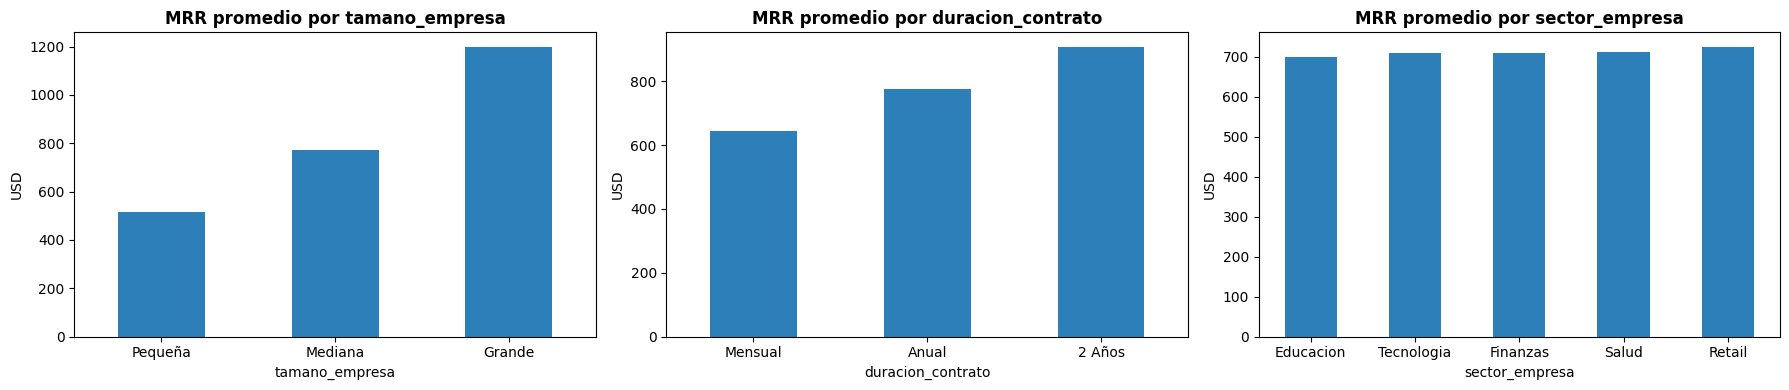

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["tamano_empresa", "duracion_contrato", "sector_empresa"]):
    orden = d_eda.groupby(col)["mrr_proximo_trimestre"].mean().sort_values().index
    d_eda.groupby(col)["mrr_proximo_trimestre"].mean().loc[orden].plot(kind="bar", ax=ax, color="#2c7fb8")
    ax.set_title(f"MRR promedio por {col}", fontweight="bold"); ax.set_ylabel("USD")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Lectura:** el tamaño de la empresa es, por lejos, el factor más asociado al MRR, seguido del uso de la plataforma (`promedio_sesiones_mes`) y el pago puntual. La duración del contrato también marca diferencias (2 años > anual > mensual). El **sector no muestra diferencias relevantes** de MRR. La antigüedad tiene correlación lineal casi nula.

# Partición train/test **antes** de imputar y escalar

Para **no tener fuga de datos (data leakage)** el orden correcto es:

1. **Dividir** en entrenamiento y prueba.
2. **Ajustar** (`fit`) imputadores, codificadores y escaladores **solo con entrenamiento**.
3. **Aplicar** (`transform`) esos mismos parámetros al conjunto de prueba.

Si se calculara la mediana o la escala con todos los datos, el conjunto de prueba "filtraría" información al entrenamiento y las métricas saldrían artificialmente buenas. Usar un `Pipeline` garantiza este orden automáticamente.

In [138]:
target = "mrr_proximo_trimestre"

X = data.drop(columns=[target, "id_cliente"])   # id_cliente es solo un identificador, no predice nada
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

Train: 24,000 filas | Test: 6,000 filas


---
---
# Fase 2 – Limpieza y tratamiento de datos

---
## 2.1 Criterio de imputación de valores nulos

Antes de definir el método de imputación, se revisó la distribución de las variables y la presencia de valores atípicos. Esto es importante porque la **media puede verse afectada por valores extremos**, por lo que no siempre representa adecuadamente el comportamiento típico de una variable.

A partir del análisis exploratorio realizado en la Fase 1, se definieron los siguientes criterios de imputación:

| Variable | Evidencia del EDA | Estadístico elegido | Justificación |
|---|---|---|---|
| `promedio_sesiones_mes` | Asimetría ≈ 2, ~5 % de atípicos, media mayor que la mediana | **Mediana** | Es menos sensible a valores atípicos y representa mejor el comportamiento central de la variable |
| `tickets_soporte` | Conteo discreto de valores enteros | **Moda** | Mantiene un valor entero válido dentro de la distribución observada |
| `satisfaccion_nps` | Escala discreta de 1 a 10 | **Moda** | Permite mantener un valor válido dentro de la escala |
| `gasto_mkt_asociado` | Sin valores nulos | — | No requiere imputación |

En este caso, la media no se utiliza para las variables con valores faltantes, ya que el análisis previo muestra que existen distribuciones donde su uso podría verse afectado por valores extremos. Por esta razón, se utilizan medidas más robustas como la **mediana** y la **moda**.

Además, para el escalado de las variables continuas se utiliza `RobustScaler`, que trabaja con la mediana y el rango intercuartílico, reduciendo la influencia de posibles valores atípicos.

A continuación se compara el efecto de estas decisiones utilizando los datos del dataset.

In [139]:
# Solo con TRAIN (para no filtrar información del test)
s = X_train["promedio_sesiones_mes"].dropna()
q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
sin_atipicos = s[(s >= q1 - 1.5 * iqr) & (s <= q3 + 1.5 * iqr)]

sens = pd.DataFrame({
    "valor": [s.mean(), s.median(), sin_atipicos.mean()],
}, index=["Media con atípicos", "Mediana", "Media sin atípicos (IQR)"])
sens["diferencia vs mediana"] = sens["valor"] - s.median()
sens

,valor,diferencia vs mediana
Media con atípicos,50.253,13.697
Mediana,36.557,0.000
Media sin atípicos (IQR),43.500,6.943


Media    =  50.25 sesiones/mes
Mediana  =  36.56 sesiones/mes
La media está 37% por encima de la mediana solo por efecto de los atípicos.
Si se quitan los atípicos, la media cae a 43.50.

Mediana de la variable tras imputar:
  Original (sin nulos)   : 36.56
  Imputada con la media  : 39.06
  Imputada con la mediana: 36.56


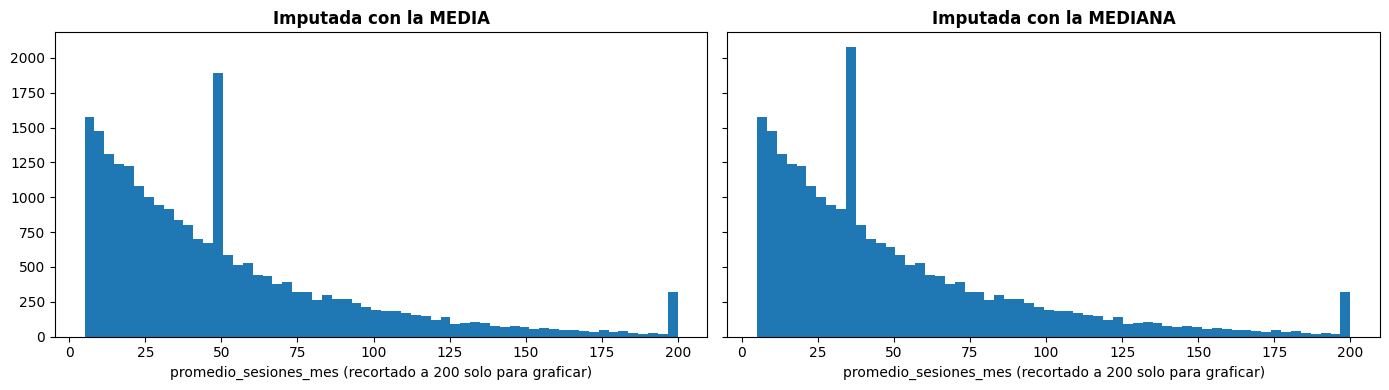

In [140]:
media_val, mediana_val = s.mean(), s.median()
print(f"Media    = {media_val:6.2f} sesiones/mes")
print(f"Mediana  = {mediana_val:6.2f} sesiones/mes")
print(f"La media está {100*(media_val/mediana_val-1):.0f}% por encima de la mediana solo por efecto de los atípicos.")
print(f"Si se quitan los atípicos, la media cae a {sin_atipicos.mean():.2f}.")

# ¿Qué pasa con la distribución al imputar con cada estadístico?
imp_media = X_train["promedio_sesiones_mes"].fillna(media_val)
imp_mediana = X_train["promedio_sesiones_mes"].fillna(mediana_val)
print("\nMediana de la variable tras imputar:")
print(f"  Original (sin nulos)   : {s.median():.2f}")
print(f"  Imputada con la media  : {imp_media.median():.2f}")
print(f"  Imputada con la mediana: {imp_mediana.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, serie, tit in zip(axes, [imp_media, imp_mediana], ["Imputada con la MEDIA", "Imputada con la MEDIANA"]):
    serie.clip(upper=200).hist(bins=60, ax=ax, grid=False)
    ax.set_title(tit, fontweight="bold"); ax.set_xlabel("promedio_sesiones_mes (recortado a 200 solo para graficar)")
plt.tight_layout(); plt.show()

**Conclusión:** rellenar con la media introduce un pico artificial en ~50 sesiones, un valor **más alto que el del cliente típico** (~36) por culpa de los atípicos. La mediana mantiene el centro de la distribución original. Por eso se usa **mediana** para `promedio_sesiones_mes`.

Más abajo (sección 3.3) se verifica además el efecto de esta decisión sobre las métricas del modelo, comparando media vs mediana vs mediana + recorte de atípicos.

---
## 2.2 ¿Se eliminan o se recortan los atípicos?

Los atípicos de `promedio_sesiones_mes` **no son errores de captura** (no hay valores negativos ni imposibles): son clientes con uso muy intenso, y ese uso está relacionado con un MRR mayor. Eliminarlos o recortarlos borra información real. Se decide **conservarlos** y neutralizar su efecto con métodos robustos (mediana para imputar, `RobustScaler` para escalar). En la sección 3.3 se prueba también el recorte (winsorización) para confirmar la decisión con datos.

---
## 2.3 Ingeniería de características y codificación categórica

Se crea un transformador propio (`FeatureEngineering`) que hace, de forma reproducible dentro del pipeline:

- **`antiguedad_dias`**: días entre `fecha_registro` y una **fecha de referencia fija** (1 de enero de 2026, día posterior a la última alta del dataset). Se usa una constante y no `today()` para que el resultado sea reproducible.
- **`tamano_empresa` → Ordinal Encoding** (tiene jerarquía): Pequeña = 0, Mediana = 1, Grande = 2.
- **`duracion_contrato` → numérico** (tiene orden natural y se mide en tiempo): Mensual = 1, Anual = 12, 2 Años = 24 (meses de compromiso).
- **`pago_puntual` → binario**: Si = 1, No = 0.
- **`sector_empresa` → One-Hot Encoding** (nominal, sin jerarquía), con `drop="first"` para evitar multicolinealidad perfecta (trampa de las variables ficticias) en la regresión lineal. Esto se hace dentro del `ColumnTransformer`.

Estos mapeos son **reglas fijas** (no aprenden de los datos), por lo que no generan fuga de datos.

In [141]:
FECHA_REFERENCIA = pd.Timestamp("2026-01-01")

class FeatureEngineering(BaseEstimator, TransformerMixin):
    """
    Ingeniería de características y codificación de variables con orden.

    Columnas nuevas: antiguedad_dias (días desde fecha_registro hasta FECHA_REFERENCIA),
    tamano_empresa_ord (Pequeña=0, Mediana=1, Grande=2), duracion_meses (Mensual=1,
    Anual=12, 2 Años=24) y pago_puntual_bin (Si=1, No=0).
    Elimina las columnas originales que fueron transformadas.
    """
    MAP_TAMANO = {"Pequeña": 0, "Mediana": 1, "Grande": 2}
    MAP_DURACION = {"Mensual": 1, "Anual": 12, "2 Años": 24}
    MAP_PAGO = {"Si": 1, "No": 0}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        fecha = pd.to_datetime(X["fecha_registro"])
        X["antiguedad_dias"] = (FECHA_REFERENCIA - fecha).dt.days
        X["tamano_empresa_ord"] = X["tamano_empresa"].map(self.MAP_TAMANO)
        X["duracion_meses"] = X["duracion_contrato"].map(self.MAP_DURACION)
        X["pago_puntual_bin"] = X["pago_puntual"].map(self.MAP_PAGO)
        return X.drop(columns=["fecha_registro", "tamano_empresa", "duracion_contrato", "pago_puntual"])

# Vista previa de lo que produce (no se ajusta nada)
FeatureEngineering().fit_transform(X_train).head()

,sector_empresa,tickets_soporte,promedio_sesiones_mes,satisfaccion_nps,gasto_mkt_asociado,antiguedad_dias,tamano_empresa_ord,duracion_meses,pago_puntual_bin
21753,Tecnologia,1.000,86.790,NaN,"1,378.230",1708,1,12,1
251,Tecnologia,0.000,83.170,6.000,"4,740.325",1431,1,1,0
22941,Educacion,1.000,10.278,8.000,469.537,1,0,1,0
618,Retail,2.000,30.982,6.000,"2,359.538",632,2,1,0
17090,Retail,1.000,12.262,5.000,660.622,1400,0,12,1


---
## 2.4 Tratamiento de nulos y escalado (dentro del `ColumnTransformer`)

- **Mediana + `RobustScaler`** para `promedio_sesiones_mes` (sesgada, con atípicos).
- **Moda + `RobustScaler`** para `tickets_soporte` y `satisfaccion_nps` (discretas con nulos).
- **`RobustScaler`** para `gasto_mkt_asociado`, `antiguedad_dias` y `duracion_meses` (continuas sin nulos).
- **`RobustScaler`/passthrough** para las variables ya codificadas: `tamano_empresa_ord` se escala igual que las continuas; `pago_puntual_bin` se deja como 0/1.
- **One-Hot** para `sector_empresa`.

**¿Por qué `RobustScaler` y no `StandardScaler`?** `StandardScaler` usa media y desviación estándar, ambas sensibles a atípicos (la misma razón por la que no se imputa con media). `RobustScaler` resta la mediana y divide por el rango intercuartílico, por lo que los atípicos de `promedio_sesiones_mes` no distorsionan la escala del resto de los datos. Escalar es necesario para que los coeficientes de la regresión sean comparables entre variables de magnitudes muy distintas (dólares de marketing en miles vs. sesiones en decenas).

> Nota: la regresión lineal por mínimos cuadrados no *requiere* escalado para predecir bien, pero sí lo pide la guía y facilita interpretar la importancia relativa de cada variable.

In [142]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Recorta extremos según percentiles aprendidos SOLO en train (ignora NaN). Se usa solo en la comparación 3.3."""
    def __init__(self, limits=(0.01, 0.99)):
        self.limits = limits
    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns if hasattr(X, "columns") else
                                            [f"x{i}" for i in range(np.asarray(X).shape[1])], dtype=object)
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanquantile(X, self.limits[0], axis=0)
        self.upper_ = np.nanquantile(X, self.limits[1], axis=0)
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_ if input_features is None else np.asarray(input_features, dtype=object)


def construir_preprocesador(imputer_sesiones="median", winsor=False):
    """Construye el ColumnTransformer. Los argumentos permiten comparar alternativas en 3.3."""
    pasos_sesiones = []
    if winsor:
        pasos_sesiones.append(("winsor", Winsorizer(limits=(0.01, 0.99))))
    pasos_sesiones += [
        ("imputer", SimpleImputer(strategy=imputer_sesiones)),
        ("escalado", RobustScaler()),
    ]

    sesiones = Pipeline(steps=pasos_sesiones)
    discretas = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),   # moda
        ("escalado", RobustScaler()),
    ])
    continuas = Pipeline(steps=[("escalado", RobustScaler())])
    categoricas = Pipeline(steps=[("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))])

    pre = ColumnTransformer(
        transformers=[
            ("sesiones", sesiones, ["promedio_sesiones_mes"]),
            ("discretas", discretas, ["tickets_soporte", "satisfaccion_nps"]),
            ("continuas", continuas, ["gasto_mkt_asociado", "antiguedad_dias",
                                      "duracion_meses", "tamano_empresa_ord"]),
            ("sector", categoricas, ["sector_empresa"]),
        ],
        remainder="passthrough",          # pago_puntual_bin queda como 0/1
        verbose_feature_names_out=False,
    )
    pre.set_output(transform="pandas")
    return pre

---
---
# Fase 3 – Construcción del modelo
---
## 3.1 Pipeline final (preprocesamiento + regresión lineal)

Todo queda encadenado en un único `Pipeline`. Al llamar a `fit` con el conjunto de **entrenamiento**, cada paso aprende sus parámetros (medianas, modas, escalas, categorías) solo con esos datos; al llamar a `predict` con el conjunto de **prueba**, se reutilizan esos parámetros sin recalcular nada.

In [143]:
modelo = Pipeline(steps=[
    ("feature_engineering", FeatureEngineering()),
    ("preprocesador", construir_preprocesador(imputer_sesiones="median", winsor=False)),
    ("modelo", LinearRegression()),
])

modelo.fit(X_train, y_train)
modelo

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('feature_engineering', FeatureEngineering()),
                ('preprocesador',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('sesiones',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   RobustScaler())]),
                                                  ['promedio_sesiones_mes']),
                                                 ('discretas',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('esc...
                                                   'satisfaccion_nps']),
                                                 ('continuas',
                                                  Pipeline(steps=[('escalado',
                                                                   RobustScaler())]),
                                                  ['gasto_mkt_asociado',
                                                   'antiguedad_dias',
                                                   'duracion_meses',
                                                   'tamano_empresa_ord']),
                                                 ('sector',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sector_empresa'])],
                                   verbose_feature_names_out=False)),
                ('modelo', LinearRegression())])

---
## 3.2 Verificación de que no hay fuga de datos

Se comprueba que lo que aprendió el pipeline (la mediana de `promedio_sesiones_mes`) proviene **solo del entrenamiento** y que es distinto de la mediana calculada con todo el dataset.

In [144]:
imp = modelo.named_steps["preprocesador"].named_transformers_["sesiones"].named_steps["imputer"]
print("Mediana aprendida por el pipeline (solo train):", round(imp.statistics_[0], 4))
print("Mediana de train (chequeo manual)             :", round(X_train['promedio_sesiones_mes'].median(), 4))
print("Mediana de todo el dataset (NO usada)         :", round(X['promedio_sesiones_mes'].median(), 4))

modas = modelo.named_steps["preprocesador"].named_transformers_["discretas"].named_steps["imputer"].statistics_
print("\nModas aprendidas (tickets_soporte, satisfaccion_nps):", modas)
print("Nulos en test antes de predecir:", X_test.isna().sum()[lambda v: v > 0].to_dict())

Mediana aprendida por el pipeline (solo train): 36.5565
Mediana de train (chequeo manual)             : 36.5565
Mediana de todo el dataset (NO usada)         : 36.2308

Modas aprendidas (tickets_soporte, satisfaccion_nps): [3. 7.]
Nulos en test antes de predecir: {'tickets_soporte': 492, 'promedio_sesiones_mes': 300, 'satisfaccion_nps': 718}


---
---
# Fase 4 – Evaluación e interpretación de métricas

In [145]:
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- Métricas del modelo (conjunto de prueba) ---")
print(f"{'R2':<6}: {r2:.3f}")
print(f"{'MAE':<6}: {mae:,.2f} USD")

y_pred_train = modelo.predict(X_train)
print("\n--- Control de sobreajuste ---")
print(f"R2  train: {r2_score(y_train, y_pred_train):.3f}   | R2  test: {r2:.3f}")
print(f"MAE train: {mean_absolute_error(y_train, y_pred_train):,.2f} | MAE test: {mae:,.2f}")

print("\n--- MAE en contexto ---")
print(f"MRR promedio real (test)  : {y_test.mean():,.2f} USD")
print(f"MRR mediano real (test)   : {y_test.median():,.2f} USD")
print(f"MAE / MRR promedio        : {100*mae/y_test.mean():.1f}%")

--- Métricas del modelo (conjunto de prueba) ---
R2    : 0.924
MAE   : 68.34 USD

--- Control de sobreajuste ---
R2  train: 0.919   | R2  test: 0.924
MAE train: 69.60 | MAE test: 68.34

--- MAE en contexto ---
MRR promedio real (test)  : 708.31 USD
MRR mediano real (test)   : 635.19 USD
MAE / MRR promedio        : 9.6%


---
## 4.1 Interpretación de las métricas en el contexto financiero de SaaSFlow

**R² (coeficiente de determinación)** – *proporción de la variabilidad del MRR que el modelo logra explicar.* Un R² de ≈ **0,92** significa que las variables predictoras explican alrededor del **92 % de la variación** del MRR entre clientes; solo ~8 % queda sin explicar (factores no medidos, ruido). En términos de negocio: el modelo **permite distinguir adecuadamente entre clientes con distintos niveles de ingreso**, por lo que puede servir como apoyo para **priorizar** cuentas. Además, los valores de R² de entrenamiento y de prueba son similares, por lo que **no se observan señales claras de sobreajuste** y los resultados sugieren una buena capacidad de generalización sobre datos similares.

**MAE (error absoluto medio)** – *magnitud promedio del error, en USD.* Un MAE de ≈ **68 USD** significa que, en promedio, la predicción del MRR de un cliente **se desvía en unos 68 USD/mes** de su valor real, es decir, cerca de un **10 % del MRR promedio** (~710 USD). Es un error acotado y expresado en las mismas unidades del negocio, por lo que puede utilizarse como referencia para la proyección de ingresos, pero **no debe interpretarse como una predicción exacta del MRR de cada cliente individual**. Para clientes pequeños (MRR ~500 USD), 68 USD representan proporcionalmente un error mayor que para clientes grandes.

**Lectura conjunta:** R² alto + MAE ≈ 10 % del MRR promedio → el modelo muestra un **buen desempeño para apoyar la proyección de ingresos y la priorización de Customer Success**, considerando que se trata de un modelo lineal y que puede presentar mayores errores en los extremos (clientes con MRR muy alto).

---
## 4.2 Diagnóstico gráfico del modelo

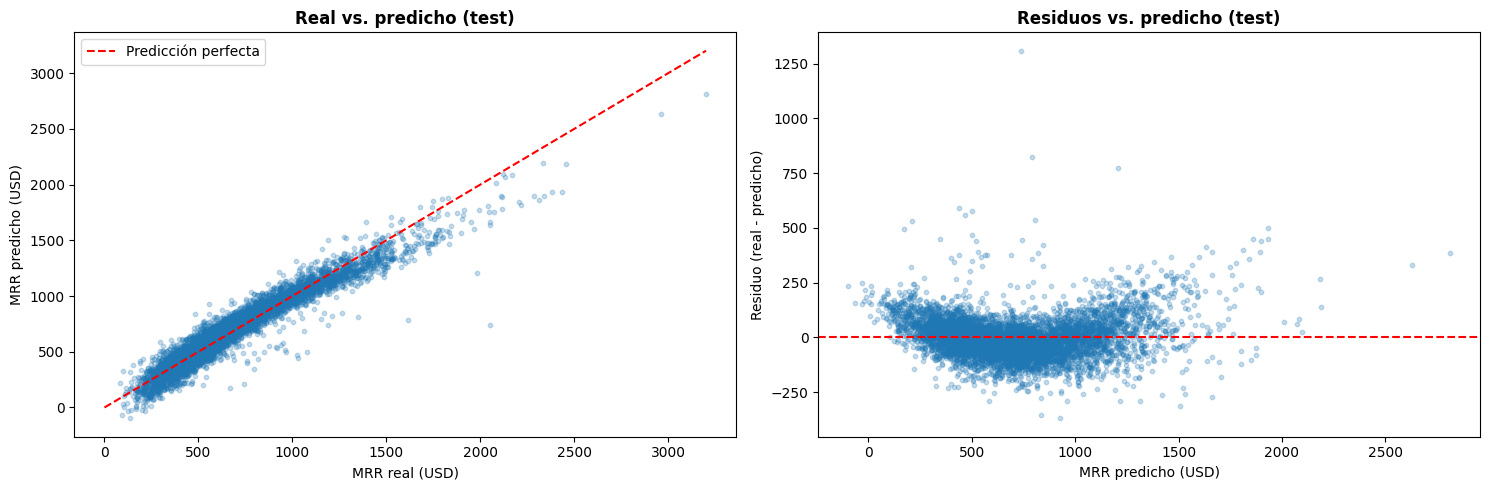

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, y_pred, alpha=0.25, s=10)
lim = [0, max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, "r--", label="Predicción perfecta")
axes[0].set_xlabel("MRR real (USD)"); axes[0].set_ylabel("MRR predicho (USD)")
axes[0].set_title("Real vs. predicho (test)", fontweight="bold"); axes[0].legend()

residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.25, s=10)
axes[1].axhline(0, color="r", ls="--")
axes[1].set_xlabel("MRR predicho (USD)"); axes[1].set_ylabel("Residuo (real - predicho)")
axes[1].set_title("Residuos vs. predicho (test)", fontweight="bold")
plt.tight_layout(); plt.show()

**Lectura:** los puntos siguen de cerca la diagonal (buen ajuste general). Los residuos se abren un poco en los valores predichos altos: el error absoluto es mayor en clientes con MRR alto (esperable en una variable asimétrica a la derecha).

In [147]:
# Error por tamaño de empresa (útil para el negocio)
X_test_eval = X_test.copy()
X_test_eval["real"] = y_test
X_test_eval["pred"] = y_pred
X_test_eval["error_abs"] = (X_test_eval["real"] - X_test_eval["pred"]).abs()
por_tamano = X_test_eval.groupby("tamano_empresa").agg(
    clientes=("real", "size"),
    MRR_promedio=("real", "mean"),
    MAE=("error_abs", "mean"),
)
por_tamano["MAE / MRR"] = 100 * por_tamano["MAE"] / por_tamano["MRR_promedio"]
por_tamano.loc[["Pequeña", "Mediana", "Grande"]]

,clientes,MRR_promedio,MAE,MAE / MRR
tamano_empresa,,,,
Pequeña,2969,512.167,60.395,11.792
Mediana,2097,766.185,69.291,9.044
Grande,934,"1,201.889",91.436,7.608


---
## 4.3 Variables con mayor asociación con el MRR futuro

Como las variables están escaladas con `RobustScaler` (comparables entre sí), permite comparar de forma aproximada el peso relativo dentro del modelo. El signo indica la dirección del efecto.

In [148]:
nombres = modelo.named_steps["preprocesador"].get_feature_names_out()
coefs = pd.Series(modelo.named_steps["modelo"].coef_, index=nombres)
coef_df = (coefs.to_frame("coeficiente")
                .assign(abs_coef=lambda d: d["coeficiente"].abs())
                .sort_values("abs_coef", ascending=False)
                .drop(columns="abs_coef"))
print("Intercepto:", round(modelo.named_steps["modelo"].intercept_, 2))
coef_df

Intercepto: 563.33


,coeficiente
tamano_empresa_ord,323.367
pago_puntual_bin,204.258
promedio_sesiones_mes,184.396
duracion_meses,124.560
gasto_mkt_asociado,57.381
satisfaccion_nps,43.669
tickets_soporte,-35.299
sector_empresa_Retail,2.531
sector_empresa_Finanzas,0.675
antiguedad_dias,-0.529


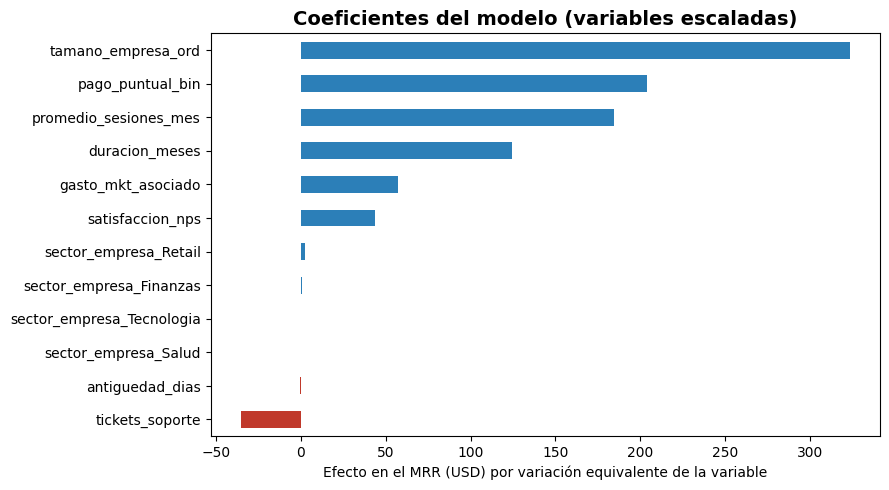

In [149]:
ax = coef_df["coeficiente"].sort_values().plot(kind="barh", figsize=(9, 5),
        color=["#c0392b" if v < 0 else "#2c7fb8" for v in coef_df["coeficiente"].sort_values()])
ax.set_title("Coeficientes del modelo (variables escaladas)", fontsize=14, fontweight="bold")
ax.set_xlabel("Efecto en el MRR (USD) por variación equivalente de la variable")
plt.tight_layout(); plt.show()

**Lectura:**

1. **`tamano_empresa_ord`** – la variable más influyente: pasar de un tamaño al siguiente eleva el MRR de forma muy marcada.
2. **`pago_puntual_bin`** y **`promedio_sesiones_mes`** – pago puntual y mayor uso de la plataforma se asocian a un MRR claramente mayor.
3. **`duracion_meses`** – contratos más largos (anual, 2 años) se asocian a mayor MRR.
4. **`gasto_mkt_asociado`** y **`satisfaccion_nps`** – efectos positivos moderados.
5. **`tickets_soporte`** – efecto **negativo**: más tickets abiertos se asocian a menor MRR (posible señal de fricción/riesgo de fuga).
6. **`sector_empresa` y `antiguedad_dias`** – aportan prácticamente nada una vez controlados los demás factores.

---
## 4.4 Comprobación empírica de la decisión de imputación (media vs. mediana vs. recorte)

Para comparar el efecto de distintas estrategias de imputación, se entrena el mismo modelo con tres tratamientos de `promedio_sesiones_mes`, **todos con la misma partición train/test**:

- **A.** Imputar con la **media** (lo que se cuestionó).
- **B.** Imputar con la **mediana** (decisión adoptada).
- **C.** **Recortar atípicos** (percentiles 1–99, aprendidos solo en train) y luego imputar con la mediana.

In [150]:
def evaluar(imputer, winsor):
    m = Pipeline(steps=[
        ("feature_engineering", FeatureEngineering()),
        ("preprocesador", construir_preprocesador(imputer_sesiones=imputer, winsor=winsor)),
        ("modelo", LinearRegression()),
    ]).fit(X_train, y_train)
    p = m.predict(X_test)
    return {"R2 test": r2_score(y_test, p), "MAE test (USD)": mean_absolute_error(y_test, p)}

comparacion = pd.DataFrame({
    "A. Media": evaluar("mean", False),
    "B. Mediana (adoptada)": evaluar("median", False),
    "C. Recorte 1-99% + mediana": evaluar("median", True),
}).T
comparacion

,R2 test,MAE test (USD)
A. Media,0.925,68.370
B. Mediana (adoptada),0.924,68.336
C. Recorte 1-99% + mediana,0.918,69.302


**Lectura:** las diferencias entre A y B son **prácticamente nulas** (centésimas de R² y centavos de MAE): el modelo es robusto a esta decisión porque solo ~5 % de `promedio_sesiones_mes` es nulo. Esto **no invalida** el argumento metodológico: imputar con la media sí distorsiona la variable (sección 2.1) y, con más nulos o más atípicos, el efecto sobre el modelo podría ser mayor. Se adopta la mediana por ser la opción **segura y justificable sin depender de la suerte de este dataset**. Recortar atípicos (C) incluso **empeora levemente** el resultado, porque elimina información legítima de clientes con uso intensivo; por eso se **conservan**.

---
## 4.5 Uso del modelo con clientes nuevos

In [151]:
nuevos = pd.DataFrame({
    "fecha_registro": ["2024-03-15", "2022-08-01", "2025-06-10"],
    "sector_empresa": ["Tecnologia", "Finanzas", "Salud"],
    "tamano_empresa": ["Grande", "Mediana", "Pequeña"],
    "tickets_soporte": [1, 4, 3],
    "promedio_sesiones_mes": [120.0, 35.0, 25.0],
    "satisfaccion_nps": [9, np.nan, 5],   # un nulo: el pipeline lo imputa solo
    "duracion_contrato": ["2 Años", "Anual", "Mensual"],
    "gasto_mkt_asociado": [3500.0, 2000.0, 1200.0],
    "pago_puntual": ["Si", "Si", "No"],
})
pred_nuevos = modelo.predict(nuevos)
nuevos.assign(MRR_predicho_USD=pred_nuevos.round(2))[["tamano_empresa", "duracion_contrato", "pago_puntual", "MRR_predicho_USD"]]

,tamano_empresa,duracion_contrato,pago_puntual,MRR_predicho_USD
0,Grande,2 Años,Si,"1,785.570"
1,Mediana,Anual,Si,855.760
2,Pequeña,Mensual,No,118.840


Ejemplo de tres clientes hipotéticos (el segundo tiene un nulo en `satisfaccion_nps`, que el pipeline imputa solo). Basta con entregar los datos crudos: el pipeline convierte la fecha, codifica, imputa y escala con los parámetros aprendidos en entrenamiento. Así, el modelo puede utilizarse para generar predicciones sobre nuevos registros con la misma estructura.

---
---

# Conclusiones

1. **Calidad de datos:** 3 variables con nulos (NPS ~12 %, tickets ~8 %, sesiones ~5 %), fecha en formato texto y `promedio_sesiones_mes` fuertemente sesgada con ~5 % de atípicos.
2. **Tratamiento:** imputación con **mediana** (variable sesgada) y **moda** (variables discretas) —no con media, por su sensibilidad a atípicos—, ingeniería de `antiguedad_dias`, codificación ordinal/binaria/one-hot y escalado robusto, todo ajustado **solo con train** (sin data leakage).
3. **Modelo:** regresión lineal con **R² ≈ 0,92** y **MAE ≈ 68 USD** (≈ 10 % del MRR promedio) en el conjunto de prueba, sin señales claras de sobreajuste.
4. **Negocio:** las variables con mayor asociación con el MRR futuro son **tamaño de la empresa**, el **uso de la plataforma** y el **pago puntual**; los **tickets de soporte** se asocian negativamente. Esto permite priorizar acciones de Customer Success sobre clientes con bajo uso, muchos tickets o pagos impuntuales.